In [5]:
from langchain_community.llms import Ollama  # Ollama LLM 사용
from langchain_core.prompts import PromptTemplate  # 프롬프트 템플릿
from langgraph.graph import StateGraph, END  # LangGraph 상태 머신
from typing import TypedDict  # 타입 정의용


# 상태(State) 정의
class AgentState(TypedDict):
    query: str                 # 사용자 질문
    symptoms: str              # 추출된 증상
    exercise_candidates: str   # 추천 운동 후보
    result: str                # 최종 답변

In [6]:
# LLM 초기화
llm = Ollama(model="exaone3.5:2.4b")

In [7]:
# 증상 추출 에이전트
extractor_prompt = PromptTemplate.from_template("""
사용자의 질문에서 운동이 필요한 증상 또는 상태를 단어 또는 구로 추출하세요.
결과는 쉼표로 구분된 문자열로 출력하세요
질문:{query}
""")


def extractor_agent(state: AgentState):

    chain = extractor_prompt | llm

    symptoms = chain.invoke({
        "query": state["query"]
    })

    return {
        **state,
        "symptoms": symptoms.strip()
    }


In [8]:
# 운동 추천 후보 에이전트
matcher_prompt = PromptTemplate.from_template("""
다음 증상을 목록을 바탕으로 해결하는데 도움이 되는 운동을 3개 추천하세요.
쉼표로 구분된 문자열로 출력하세요
증상:{symptoms}
""")


def matcher_agent(state: AgentState):

    chain = matcher_prompt | llm

    candidates = chain.invoke({
        "symptoms": state["symptoms"]
    })

    return {
        **state,
        "exercise_candidates": candidates.strip()
    }

In [ ]:
# 최종 답변 생성 에이전트
answer_prompt = PromptTemplate.from_template("""
사용자의 증상의 증상은 다음과 같습니다 : {symptoms}
추천 운동: {exercise_candidates}
위 내용을 바탕으로 사용자에게 알기쉽게 개조식으로 설명하세요.
출력 형식 예시:
- 증상:
- 추천 운동:
- 운동 추천 이유:
""")


def answer_agent(state: AgentState):

    chain = answer_prompt | llm

    answer = chain.invoke({
        "symptoms": state["symptoms"],
        "exercise_candidates": state["exercise_candidates"]
    })

    return {
        **state,
        "result": answer.strip()
    }

In [10]:
# LangGraph 구성
graph = StateGraph(AgentState)

# 노드 추가
graph.add_node("extractor", extractor_agent)
graph.add_node("matcher", matcher_agent)
graph.add_node("answer", answer_agent)

# 시작 노드 설정
graph.set_entry_point("extractor")

# 노드 연결
graph.add_edge("extractor", "matcher")
graph.add_edge("matcher", "answer")
graph.add_edge("answer", END)

# 그래프 컴파일
app = graph.compile()

In [11]:
# 실행
query = "체력이 안좋고, 살이 계속 찌는데 어떤 운동을 할까?"

result = app.invoke({
    "query": query
})

print("\n============= 최종 응답 =============")
print(result["result"])


============= 최종 응답 =============
### 사용자 건강 개선 가이드

#### - 증상:
- **체력 저하**
- **체중 증가**

#### - 추천 운동 및 이유:

**1. 고강도 인터벌 트레이닝 (HIIT)**
   - **주기**: 주 3-4회 실시
   - **효과**: 짧은 시간 동안 매우 높은 강도의 운동을 반복하여 효율적으로 칼로리 소모를 증가시킵니다.
   - **예시**: 30초 고속 달리기 후 1분간 휴식을 반복 (총 세트 수에 따라 조정 가능)

**2. 유산소 운동**
   - **활동 종류**: 달리기, 자전거 타기
   - **효과**: 지속적인 심장 및 폐 기능 강화와 체지방 감소에 효과적입니다.
   - **실시 방법**: 일주일에 최소 3회, 각 세션 30분 이상 진행
   - **팁**: 천천히 시작하여 점차 속도와 강도를 높여가세요.

**3. 근력 훈련 및 체중 조절 운동**
   - **기본 운동**: 플랭크, 스쿼트, 런지
   - **효과**: 근육량 증가로 기초대사량을 높이고, 근육 유지로 인해 지속적인 칼로리 소모가 가능합니다.
   - **실시 방법**: 각 운동 3-4세트, 각 세트당 12-15회 반복
   - **주의**: 올바른 자세 유지와 점진적인 운동 강도 증가가 중요합니다. 초보자는 전문가의 지도를 받는 것을 추천드립니다.

#### **종합 조언**:
- **일관성**: 매주 꾸준히 운동 일정을 유지하여 습관화하는 것이 중요합니다.
- **다양성**: 운동 종류를 다양하게 섞어 지루함을 방지하고 균형 잡힌 발달을 촉진하세요.
- **식습관**: 운동과 함께 균형 잡힌 식단 관리로 체중 조절 효과를 극대화하세요.

이러한 계획을 통해 체력 향상과 체중 관리 모두에 효과적으로 대응할 수 있을 것입니다. 필요시 전문가와 상의하여 개인 맞춤형 조언을 받아보시는 것도 좋은 방법입니다.


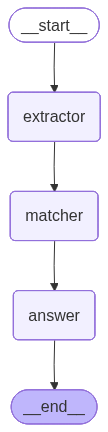

============================== LangGraph 구조
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
+-----------+  
| extractor |  
+-----------+  
      *        
      *        
      *        
 +---------+   
 | matcher |   
 +---------+   
      *        
      *        
      *        
  +--------+   
  | answer |   
  +--------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


In [4]:
# ==================================================
# 8. 그래프 시각화
# ==================================================
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

print("============================== LangGraph 구조")
app.get_graph().print_ascii()

